# CSC AI Summer School 2026 - day 5: Evaluation

### Task: do some post-market surveillance.

In this tutorial, we're doing minimal coding, we're mostly thinking!

This tutorial loads audit data for an AI model that has ran on approximately 22000 patients over a period of 9 months.

The model is a pulmonary embolism (PE) detector from aidoc.

The Aidoc platform runs two models:
1) **PE**: if a patient has received a CT pulmonary angiogram, the PE model runs.
2) **IPE**: if the patient has received contrast-enhanced CT of the lung region, the IPE (I for incidental) model runs.

Both models (IPE and PE) output a classification: PE or no PE. The AI classification has been reviewed by experts, such that each example
contains a confusion matrix label (true positive TP, true negative TN, false positive FP, false negative FN).

One of the models (IPE) received an upgrade in 2025-09.

We're doing three things in this tutorial as a taste of post-deployment surveillance:

(1) population: monitor who we scanned, see if there are changes over time.

(2) performance: monitor the performance of the models over time.

(3) deeper analysis: analyse any trends we've identified.

Run the cell below to get started.

In [1]:
# Run this block to import and create relevant functions - don't spend time reading this!

%pip install gdown --quiet
import gdown
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
from pathlib import Path
import zipfile

%matplotlib inline
COLORS = {"IPE": "tab:blue", "PE": "tab:red"}

def load():

    Path("./content").mkdir(exist_ok=True)
    DATASET_ZIP = Path("./content/dataset.zip")  # path of the zip file to be downloaded; this will be deleted after extraction.
    DATA_PATH = os.path.join("./content/aidoc_audit.csv")

    gdown.download(id="1fI2ZNFd4AXiUDtYE8jCKJx2auLd9ASuI", output=str(DATASET_ZIP), quiet=False)
    with zipfile.ZipFile(DATASET_ZIP, "r") as z:
        z.extractall("./content/")
    
    DATASET_ZIP.unlink()  # delete the zip

    df = pd.read_csv(DATA_PATH, parse_dates=["acquisition_time"])
    df["month"] = df["acquisition_time"].dt.to_period("M").dt.to_timestamp()
    return df


def confusion_matrix(df):

    v = df["confusion_matrix"].value_counts()
    return pd.DataFrame(
        [[v.get("TP", 0), v.get("FN", 0)],
         [v.get("FP", 0), v.get("TN", 0)]],
        index=["actual: PE", "actual: no PE"],
        columns=["predicted: PE", "predicted: no PE"],
    )


def wilson_ci(k, n, z=1.96):
    """95% Wilson interval for a proportion k/n, returned as (low, high) in percent."""

    p = k / n
    centre = (p + z * z / (2 * n)) / (1 + z * z / n)
    half = z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / (1 + z * z / n)
    return 100 * (centre - half), 100 * (centre + half)


def shade_upgrade(ax, upgrade, end):
    UPGRADE_COLOR = "gray"   # the post-upgrade period is shaded this colour
    ax.axvspan(upgrade, end, color=UPGRADE_COLOR, alpha=0.15, lw=0,
               zorder=0, label="IPE upgrade")


def line_panel(ax, mm, key, title, ylabel, upgrade):

    months = mm.index.get_level_values("month")
    start = months.min() - pd.Timedelta(days=15)
    end = months.max() + pd.Timedelta(days=15)
    shade_upgrade(ax, upgrade, end)
    for mod in ["IPE", "PE"]:
        s = mm.xs(mod, level="ai_module")[key]
        ax.plot(s.index, s, "o-", color=COLORS[mod], lw=2,
                label=f"{mod} (monthly average)")
        ax.axhline(s.mean(), color=COLORS[mod], ls="--", lw=1, alpha=0.4,
                   label=f"{mod} (historic mean: {s.mean():.1f}%)")
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_ylim(bottom=0)
    ax.set_xlim(start, end)
    ax.grid(alpha=0.3)
    ax.legend(fontsize=8)


def finish(fig, suptitle, name):
    FIG_DIR = "./content/figures"
    for ax in fig.axes:
        ax.tick_params(axis="x", rotation=30)
    fig.suptitle(suptitle, fontsize=14)
    fig.tight_layout()
    os.makedirs(FIG_DIR, exist_ok=True)
    fig.savefig(os.path.join(FIG_DIR, name), dpi=110)



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


## Load the audit data and plot some confusion matrices

> *There is nothing to code in this cell - just read the text below and run the cell after.*

We start by getting familiar with the data. The data is automatically loaded with the `load()` helper. We print a few examples of the data so that you can familiarise yourself with it, and then we calculate the confusion matrix for each model (PE, IPE).

Make sure that you're attentive to the numbers in the confusion matrices - this should help you understand if the disease is prevalent or not, and how often each model is used.

In [2]:
df = load()

print("Sample of the data:")
print(df[["patient_id", "acquisition_time", "ai_module", "model_no", "confusion_matrix"]].sample(n=10).to_string(index=False))
print("="*70 + "\n")

# For each model (PE, IPE) we'll look at confusion matrices.
for mod in ["IPE", "PE"]:
    print(f"{mod} model")
    display(confusion_matrix(df[df["ai_module"] == mod]))

Downloading...
From: https://drive.google.com/uc?id=1fI2ZNFd4AXiUDtYE8jCKJx2auLd9ASuI
To: /Users/msimard/Software/summer-school-tutorials/day5_evaluation/2026/content/dataset.zip
100%|██████████| 136k/136k [00:00<00:00, 5.64MB/s]

Sample of the data:
 patient_id    acquisition_time ai_module  model_no confusion_matrix
      20009 2025-10-14 11:17:00        PE         1               TN
      17065 2025-09-08 14:16:00       IPE         2               TN
      21019 2025-11-06 10:35:00       IPE         2               TN
      15216 2025-08-24 12:15:00       IPE         1               TN
      13348 2025-07-27 00:04:00        PE         1               TN
        526 2025-04-03 09:05:00       IPE         1               TN
       2266 2025-03-22 22:31:00        PE         1               FP
       6151 2025-05-11 09:47:00       IPE         1               TN
         19 2025-05-28 12:28:00       IPE         1               TN
      20341 2025-11-01 13:51:00       IPE         2               TN

IPE model


,predicted: PE,predicted: no PE
actual: PE,74,533
actual: no PE,163,18702


PE model


,predicted: PE,predicted: no PE
actual: PE,29,193
actual: no PE,200,1441


## Compute the monthly metrics

The function `monthly_metrics` below builds a table (`tb`) that contain confusion matrix counts indexed by month and model.

We will add useful monthly metrics calculated from the confusion matrix counts for further analysis.

The code already includes `N`, the total number of examples, and `usage_share`, the ratio of each model (PE, IPE) being called on a monthly basis, as two variables of interest.

<font color="red">This is the only place where we request code in this tutorial - please fill the remainining three metrics below (positive predictive value (ppv), detection rate, and prevalence) from the variables TP, TN, FN, FP, and N.</font> 

In [3]:
def monthly_metrics(df):
    """Per (month, module): usage share + PPV / detection rate / prevalence."""
    tb = pd.crosstab([df["month"], df["ai_module"]], df["confusion_matrix"])
    TP, TN, FP, FN = tb["TP"], tb["TN"], tb["FP"], tb["FN"]
    N = TP + TN + FP + FN
    tb["n"] = N
    tb["usage_share"] = 100 * N / tb.groupby(level="month")["n"].transform("sum")

    # TODO: fill in the three metrics below (each as a percentage)

    # Fill the positive predictive value, ppv, as a percentage:
    tb["ppv"] = 100 * TP / (TP + FP)

    # Fill the detection rate, as a percentage:
    tb["detection_rate"] = 100 * TP / N

    # Fill the prevalence, as a percentage:
    tb["prevalence"] = 100 * (TP + FN) / N
    return tb

# Produce those monthly metrics that we'll plot now:
mm = monthly_metrics(df)
upgrade = df.loc[df["model_no"] == 2, "month"].min()  # IPE upgrade (September)
mm.sample(n=10)

confusion_matrix      FN  FP    TN  TP     n  usage_share        ppv  \
month      ai_module                                                   
2025-09-01 IPE        71  24  2220   7  2322    90.703125  22.580645   
2025-06-01 IPE        55  20  2338   7  2420    92.050209  25.925926   
           PE         25  28   155   1   209     7.949791   3.448276   
2025-11-01 PE          8   6    68   2    84     8.842105  25.000000   
2025-07-01 IPE        86  23  2373  11  2493    91.251830  32.352941   
2025-11-01 IPE        28   3   829   6   866    91.157895  66.666667   
2025-05-01 IPE        75  25  2359   6  2465    92.634348  19.354839   
2025-07-01 PE         22  36   178   3   239     8.748170   7.692308   
2025-05-01 PE         22  30   143   1   196     7.365652   3.225806   
2025-04-01 PE         23  19   187   3   232     8.926510  13.636364   

confusion_matrix      detection_rate  prevalence  
month      ai_module                              
2025-09-01 IPE              0.301464    3.359173  
2025-06-01 IPE              0.289256    2.561983  
           PE               0.478469   12.440191  
2025-11-01 PE               2.380952   11.904762  
2025-07-01 IPE              0.441235    3.890895  
2025-11-01 IPE              0.692841    3.926097  
2025-05-01 IPE              0.243408    3.286004  
2025-07-01 PE               1.255230   10.460251  
2025-05-01 PE               0.510204   11.734694  
2025-04-01 PE               1.293103   11.206897

## 1. Population

> *There is nothing to code in this cell - just read the text below and run the cell after.*

As part of surveillance, we should monitor the population on which the model is being ran and be on the lookout for population shifts. We're using two metrics here:

1) **the model usage share**: track the ratio of IPE and PE models over time; a trend means a change in our population (ratio of CTPA to CT), or possibly a failure in DICOM metadata to trigger the correct test.
2) **disease prevalence**: are we seeing in general more or less real cases of PE over time? This can affect metrics such as positive predictive value.

Run the cell below and then you can most likely conclude on the stability of the population (for each model) for the duration of the audit.

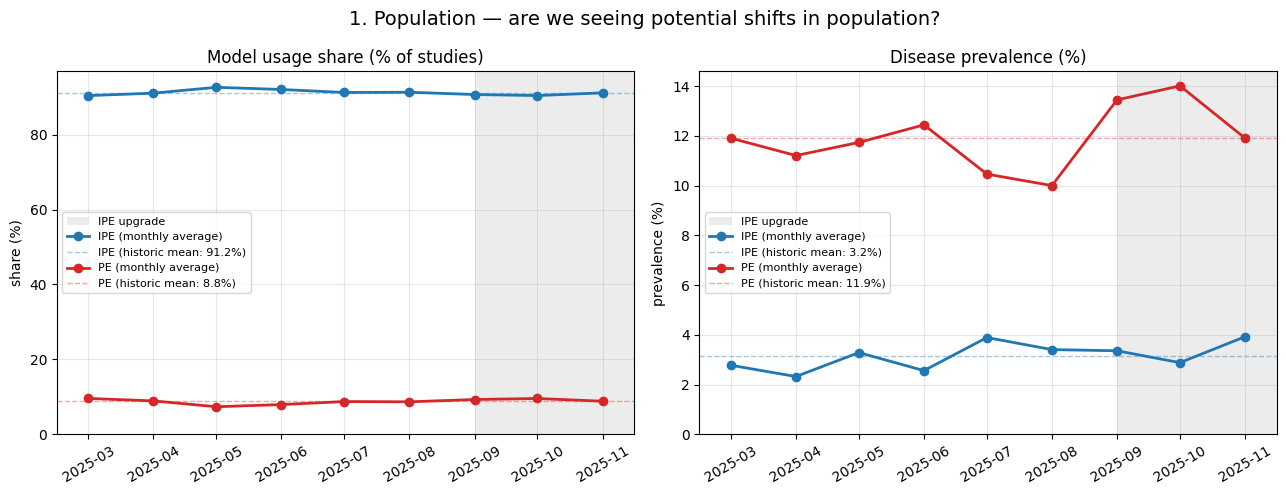

In [4]:
def plot_population(mm, upgrade):
    fig, (a, b) = plt.subplots(1, 2, figsize=(13, 5))
    line_panel(a, mm, "usage_share", "Model usage share (% of studies)",
               "share (%)", upgrade)
    line_panel(b, mm, "prevalence", "Disease prevalence (%)", "prevalence (%)", upgrade)
    finish(fig, "1. Population — are we seeing potential shifts in population?", "1_population.png")


plot_population(mm, upgrade)

## 2. Performance

> *There is nothing to code in this cell - just read the text below and run the cell after.*

As you've seen above, PE is a condition with low prevalence in the use case here. 

Two useful metrics to investigate are as follows:

1) **detection rate**: tells us how often we're detecting true positives in the whole population. 
2) **positive predictive value (ppv)**: is the probability that a patient who tests positive for PE truly has PE. 

Run the cell below, and try to notice if there is structure or trends in the performance metrics, and try to come up with hypotheses to explain what you notice.

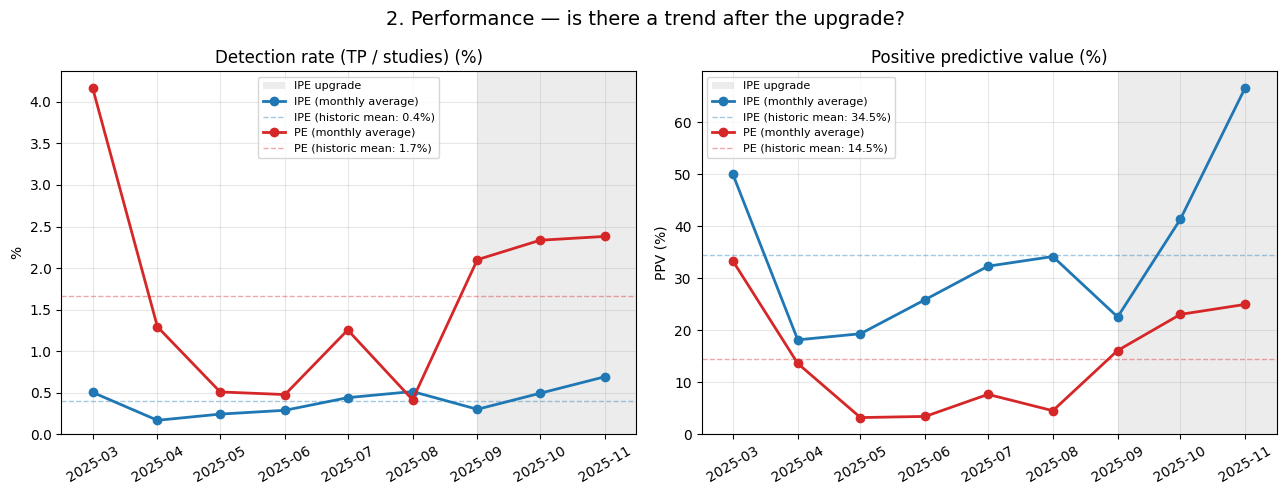

In [5]:
def plot_performance(mm, upgrade):
    fig, (a, b) = plt.subplots(1, 2, figsize=(13, 5))
    line_panel(a, mm, "detection_rate", "Detection rate (TP / studies) (%)", "%", upgrade)
    line_panel(b, mm, "ppv", "Positive predictive value (%)", "PPV (%)", upgrade)
    finish(fig, "2. Performance — is there a trend after the upgrade?", "2_performance.png")


plot_performance(mm, upgrade)

## 3. Deeper analysis

> *There is nothing to code in this cell - just read the text below and run the cell after.*

Based on the above, you may be constructing a story about the data - did the model upgrade have any potential effect? Is there any population shift effect?

To conclude this tutorial, we're looking at the specific example of the positive predictive value of the IPE model, as other metrics could be analysed in a similar way.

If you go back to the confusion matrices at the start, amongst the 19472 patients evaluated in the audit, only 74+163=237 (1.2%) have been flagged as having PE by the IPE model. Distributed over 9 months of analysis, that's 26 patients per month that we use to build statistics, which is not extremely reliable!

Run the cell below, and go see the final block for an interpretation of the results.

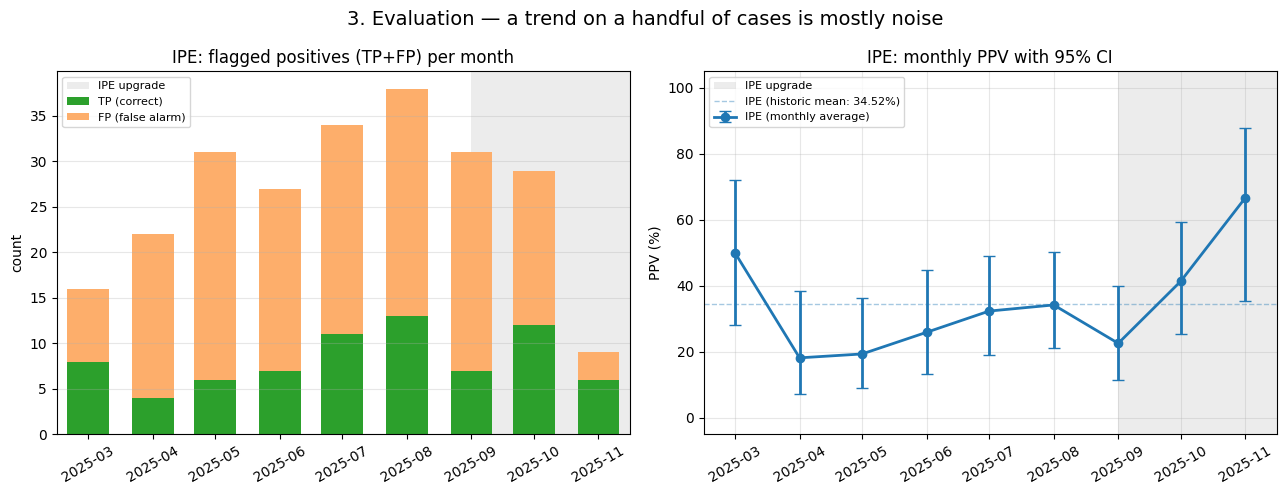

In [ ]:
def plot_evaluation(mm, upgrade, module="IPE"):
    s = mm.xs(module, level="ai_module")
    tp, fp = s["TP"], s["FP"]
    lo, hi = wilson_ci(tp, tp + fp)
    start = s.index.min() - pd.Timedelta(days=15)
    end = s.index.max() + pd.Timedelta(days=15)

    fig, (a, b) = plt.subplots(1, 2, figsize=(13, 5))

    # left: the handful of counts PPV is computed from
    shade_upgrade(a, upgrade, end)
    a.bar(s.index, tp, width=20, color="tab:green", label="TP (correct)")
    a.bar(s.index, fp, width=20, bottom=tp, color="#fdae6b", label="FP (false alarm)")
    a.set_title(f"{module}: flagged positives (TP+FP) per month")
    a.set_ylabel("count")
    a.set_xlim(start, end)
    a.grid(alpha=0.3, axis="y")
    a.legend(loc="upper left", fontsize=8)

    # right: PPV with its 95% confidence interval
    shade_upgrade(b, upgrade, end)
    b.errorbar(s.index, s["ppv"], yerr=[s["ppv"] - lo, hi - s["ppv"]],
               fmt="o-", capsize=4, color=COLORS[module], lw=2,
               label=f"{module} (monthly average)")
    b.axhline(s["ppv"].mean(), color=COLORS[module], ls="--", lw=1, alpha=0.4,
              label=f"{module} (historic mean: {s['ppv'].mean():.2f}%)")
    b.set_title(f"{module}: monthly PPV with 95% CI")
    b.set_ylabel("PPV (%)")
    b.set_ylim(-5, 105)
    b.set_xlim(start, end)
    b.grid(alpha=0.3)
    b.legend(loc="upper left", fontsize=8)

    finish(fig, "3. Evaluation",
           "3_evaluation_noise.png")


plot_evaluation(mm, upgrade)

The left hand side figure above shows you the real distribution of TP and FP across the different months of the audit, to confirm the above. You'll see that for example, in November, we only had 9 patients - that's not a lot of data!

The right hand side figure shows the same plot as what you've seen in part 2 above (positive predictive value as a function of time) but this time **with a 95% confidence interval***.

The confidence intervals are large (due to limited number of patients), and overlap with the mean for most time points.

This should help you understand the impact of measurement noise, and perhaps you can revisit your conclusions from the previous section.

> **if you want to know more about how confidence intervals have been generated, ask your instructor!*